<a href="https://colab.research.google.com/github/fggjuu/blender_project_trackers/blob/main/DLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get install -y libhdf5-serial-dev hdf5-tools
!pip install meep numpy matplotlib tqdm

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libhdf5-dev' instead of 'libhdf5-serial-dev'
libhdf5-dev is already the newest version (1.10.7+repack-4ubuntu2).
The following NEW packages will be installed:
  hdf5-tools
0 upgraded, 1 newly installed, 0 to remove and 0 not upgraded.
Need to get 347 kB of archives.
After this operation, 1,255 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 hdf5-tools amd64 1.10.7+repack-4ubuntu2 [347 kB]
Fetched 347 kB in 0s (750 kB/s)
Selecting previously unselected package hdf5-tools.
(Reading database ... 121945 files and directories currently installed.)
Preparing to unpack .../hdf5-tools_1.10.7+repack-4ubuntu2_amd64.deb ...
Unpacking hdf5-tools (1.10.7+repack-4ubuntu2) ...
Setting up hdf5-tools (1.10.7+repack-4ubuntu2) ...
Processing triggers for man-db (2.10.2-1) ...
  Installing build dependencies ... done
  Getting requirements 

In [ ]:
import meep as mp
from meep import Vector3
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json

# Функция: создать геометрию DLA
def create_dla_geometry(period, thickness, num_cells=7, epsilon=2.1):
    geometry = []
    for n in range(-num_cells // 2, num_cells // 2 + 1):
        x0 = n * period
        geometry.append(mp.Block(
            size=mp.Vector3(period * 0.9, thickness, mp.inf),
            center=mp.Vector3(x0, 0),
            material=mp.Medium(epsilon=epsilon)
        ))
    return geometry

# Функция: симуляция движения частицы по полям
def simulate_particle(path_fields, domain, dt=0.1, q=1.0, m=1.0):
    x, y = -domain.x / 2 + 0.5, 0.0
    vx = 0.0
    trajectory = []
    for field in path_fields:
        ix = int((x + domain.x / 2) / domain.x * field.shape[0])
        iy = int((y + domain.y / 2) / domain.y * field.shape[1])
        ix = max(0, min(ix, field.shape[0] - 1))
        iy = max(0, min(iy, field.shape[1] - 1))
        Ez_val = field[ix, iy]
        ax = (q * Ez_val) / m
        vx += ax * dt
        x += vx * dt
        trajectory.append((x, vx))
        if x > domain.x / 2:
            break
    return np.array(trajectory)

# Диапазоны параметров
periods = np.linspace(0.6, 1.0, 5)
thicknesses = np.linspace(0.2, 0.5, 5)
results = []

domain = mp.Vector3(10, 5, 0)

print("⚙️ Запускаем симуляции...")
for p in tqdm(periods, desc='Periods'):
    for t in thicknesses:
        geometry = create_dla_geometry(p, t)
        src = [mp.Source(mp.GaussianSource(frequency=1.0, fwidth=0.2),
                         component=mp.Ez,
                         center=mp.Vector3(-4.5, 0),
                         size=mp.Vector3(0, 3))]
        sim = mp.Simulation(
            cell_size=domain,
            resolution=40,
            boundary_layers=[mp.PML(1.0)],
            geometry=geometry,
            sources=src
        )
        fields = []
        sim.run(mp.at_every(1, lambda sim: fields.append(
            sim.get_array(center=mp.Vector3(), size=domain, component=mp.Ez)
        )), until=15)
        traj = simulate_particle(fields, domain, dt=0.1)
        final_v = traj[-1, 1] if len(traj) > 0 else 0.0
        energy = 0.5 * final_v**2
        results.append({'period': float(p), 'thickness': float(t), 'energy': float(energy)})

# Находим оптимум
best = max(results, key=lambda x: x['energy'])
print(f"🏁 Лучшие параметры: period={best['period']:.3f}, thickness={best['thickness']:.3f}, energy={best['energy']:.2e}")

# График траектории
traj_best = simulate_particle(fields, domain, dt=0.1)
if len(traj_best) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(traj_best[:, 0], label='Position (x)')
    plt.plot(traj_best[:, 1], label='Velocity (v)')
    plt.title('Динамика частицы при лучших параметрах')
    plt.xlabel('Шаг')
    plt.ylabel('Значение')
    plt.legend()
    plt.grid(True)
    plt.show()

# Сохраняем результаты
with open('sweep_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✅ Готово!")

ImportError: cannot import name 'Vector3' from 'meep' (/usr/local/lib/python3.11/dist-packages/meep/__init__.py)

<ipython-input-4-0149cc18d7d1>:70: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


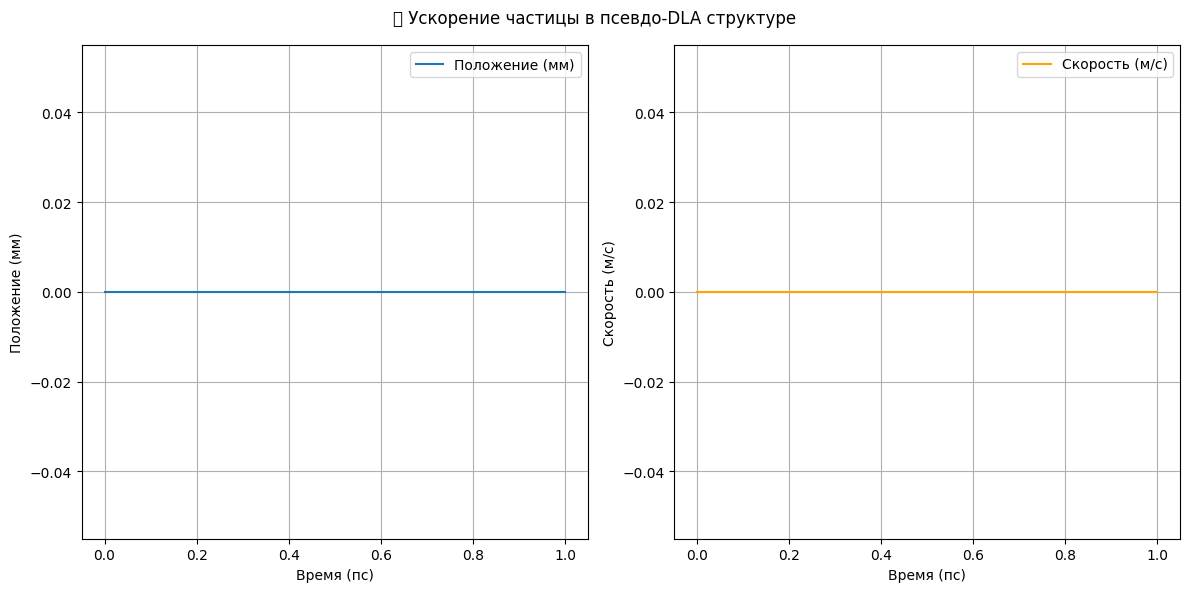

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Параметры симуляции
time_steps = 1000
dt = 1e-15  # временной шаг, сек
length = 2e-3  # длина чипа, м
num_cells = 1000
period = 2e-6  # период структуры, м

# Сетка
x = np.linspace(0, length, num_cells)
dx = x[1] - x[0]

# Электрическое поле (простая стоячая волна для wakefield)
E0 = 1e9  # В/м (примерно в диапазоне DLA)
E_field = E0 * np.sin(2 * np.pi * x / period)

# Частица
mass = 9.11e-31  # масса электрона
charge = -1.6e-19  # заряд электрона
pos = 0.0
vel = 0.0

# История движения
positions = []
velocities = []
times = []

# Основной цикл симуляции
for t in range(time_steps):
    idx = int(pos / dx)
    if 0 <= idx < len(E_field):
        E = E_field[idx]
    else:
        E = 0
    # F = qE, a = F/m
    acc = charge * E / mass
    vel += acc * dt
    pos += vel * dt

    positions.append(pos)
    velocities.append(vel)
    times.append(t * dt)

# Переведём в мм и м/с
positions = np.array(positions) * 1e3
velocities = np.array(velocities)
times = np.array(times) * 1e12  # в пикосекунды

# 📈 Визуализация
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(times, positions, label="Положение (мм)")
plt.xlabel("Время (пс)")
plt.ylabel("Положение (мм)")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(times, velocities, label="Скорость (м/с)", color="orange")
plt.xlabel("Время (пс)")
plt.ylabel("Скорость (м/с)")
plt.grid()
plt.legend()

plt.suptitle("🚀 Ускорение частицы в псевдо-DLA структуре")
plt.tight_layout()
plt.show()